<a href="https://colab.research.google.com/github/Optimus0205/Sales-Forecasting/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forcasting


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

##Task 1 — Data Loading, Merging & Deep Exploration


- Load the Superstore Sales CSV using Pandas

In [ ]:
df=pd.read_csv('/content/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.shape

(9800, 18)

- Parse the Order Date and Ship Date columns as proper datetime objects

In [ ]:
df['Order Date']=pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']=pd.to_datetime(df['Ship Date'], dayfirst=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


- Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season

In [ ]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Week Number'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Order Day of Week'] = df['Order Date'].dt.dayofweek
df['Order Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Order Season'] = df['Order Month'].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week Number,Order Day of Week,Order Quarter,Order Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,2,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,2,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,0,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,1,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,1,4,Autumn


- Check for missing values, duplicates, and data type issues


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9800 non-null   int64         
 1   Order ID           9800 non-null   object        
 2   Order Date         9800 non-null   datetime64[ns]
 3   Ship Date          9800 non-null   datetime64[ns]
 4   Ship Mode          9800 non-null   object        
 5   Customer ID        9800 non-null   object        
 6   Customer Name      9800 non-null   object        
 7   Segment            9800 non-null   object        
 8   Country            9800 non-null   object        
 9   City               9800 non-null   object        
 10  State              9800 non-null   object        
 11  Postal Code        9789 non-null   float64       
 12  Region             9800 non-null   object        
 13  Product ID         9800 non-null   object        
 14  Category

In [ ]:
df['Postal Code'].isna().sum()

np.int64(11)

In [ ]:
df[df['Postal Code'].isna()]
# Empty value of postal code for Burlington City, Vermont State, US  -> postal code value '05401'

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week Number,Order Day of Week,Order Quarter,Order Season
2234,2235,CA-2018-104066,2018-12-05,2018-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,2018,12,49,2,4,Winter
5274,5275,CA-2016-162887,2016-11-07,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,2016,11,45,0,4,Autumn
8798,8799,US-2017-150140,2017-04-06,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,2017,4,14,3,2,Spring
9146,9147,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2017,1,4,0,1,Winter
9147,9148,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,2017,1,4,0,1,Winter
9148,9149,US-2017-165505,2017-01-23,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,2017,1,4,0,1,Winter
9386,9387,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,2018,1,3,4,1,Winter
9387,9388,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,2018,1,3,4,1,Winter
9388,9389,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,2018,1,3,4,1,Winter
9389,9390,US-2018-127292,2018-01-19,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,2018,1,3,4,1,Winter


Empty value of postal code for Burlington City, Vermont State, US  -> postal code value '05401'

In [ ]:
df['Postal Code'].fillna('05401', inplace=True)

/tmp/ipykernel_2548/1714574116.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna('05401', inplace=True)
/tmp/ipykernel_2548/1714574116.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '05401' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Postal Code'].fillna('05401', inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9800 non-null   int64         
 1   Order ID           9800 non-null   object        
 2   Order Date         9800 non-null   datetime64[ns]
 3   Ship Date          9800 non-null   datetime64[ns]
 4   Ship Mode          9800 non-null   object        
 5   Customer ID        9800 non-null   object        
 6   Customer Name      9800 non-null   object        
 7   Segment            9800 non-null   object        
 8   Country            9800 non-null   object        
 9   City               9800 non-null   object        
 10  State              9800 non-null   object        
 11  Postal Code        9800 non-null   object        
 12  Region             9800 non-null   object        
 13  Product ID         9800 non-null   object        
 14  Category

In [ ]:
df.duplicated().sum()

np.int64(0)

- Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)

In [ ]:
df_sales = df[['Order Date', 'Sales']].copy()
df_sales.set_index('Order Date', inplace=True)

# Aggregate to weekly sales
df_weekly_sales = df_sales.resample('W')['Sales'].sum().reset_index()
df_weekly_sales.rename(columns={'Order Date': 'Week Start Date', 'Sales': 'Weekly Sales'}, inplace=True)

#print('Weekly Sales (first 5 rows):')
df_weekly_sales

,Week Start Date,Weekly Sales
0,2015-01-04,304.5080
1,2015-01-11,4619.1080
2,2015-01-18,4130.5330
3,2015-01-25,3092.5440
4,2015-02-01,2527.9140
5,2015-02-08,968.5340
6,2015-02-15,2771.0540
7,2015-02-22,224.9120
8,2015-03-01,2289.6430
9,2015-03-08,4030.7280


In [ ]:
# Aggregate to monthly sales
df_monthly_sales = df_sales.resample('ME')['Sales'].sum().reset_index()
df_monthly_sales.rename(columns={'Order Date': 'Month End Date', 'Sales': 'Monthly Sales'}, inplace=True)

#print('\nMonthly Sales (first 5 rows):')
df_monthly_sales

,Month End Date,Monthly Sales
0,2015-01-31,14205.7070
1,2015-02-28,4519.8920
2,2015-03-31,55205.7970
3,2015-04-30,27906.8550
4,2015-05-31,23644.3030
5,2015-06-30,34322.9356
6,2015-07-31,33781.5430
7,2015-08-31,27117.5365
8,2015-09-30,81623.5268
9,2015-10-31,31453.3930


- Answer these questions in your notebook with data to back each one:
    - Which product category generates the highest total revenue?

      **Ans** Technology

In [ ]:
df['Sales'].groupby(df['Category']).sum().reset_index(name='Total Revenue').sort_values(by='Total Revenue', ascending=False)

,Category,Total Revenue
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


- Answer
    - Which region has the most consistent sales growth over 4 years?

      **Ans** West

In [ ]:
df['Sales'].groupby(df['Region']).sum().reset_index(name='Total Revenue').sort_values(by='Total Revenue', ascending=False)

,Region,Total Revenue
3,West,710219.6845
1,East,669518.7260
0,Central,492646.9132
2,South,389151.4590


- Answer
    - What is the average time between Order Date and Ship Date — and does it vary by region?

      **Ans** No it's almost the same

In [ ]:
df['Shipping Time']=(df['Ship Date']-df['Order Date']).dt.days
df['Shipping Time'].groupby(df['Region']).mean().reset_index(name='Average Shipping Time')

,Region,Average Shipping Time
0,Central,4.065876
1,East,3.910233
2,South,3.961202
3,West,3.930255


- Answer
    - Are there months that consistently spike across all years (seasonality)?

      **Ans** Yes September, November and December

In [ ]:
df.groupby('Order Month')['Sales'].sum().reset_index(name='Total Revenue Across All Years').sort_values(by='Total Revenue Across All Years', ascending=False)


,Order Month,Total Revenue Across All Years
10,11,350161.7110
11,12,321480.1695
8,9,300103.4117
9,10,199496.2947
2,3,197573.5872
7,8,157315.9270
4,5,154086.7237
5,6,145837.5233
6,7,145535.6890
3,4,136283.0006


In [ ]:
monthly_total_revenue=df.groupby('Order Month')['Sales'].sum().reset_index(name='Total Revenue Across All Years').sort_values(by='Total Revenue Across All Years', ascending=False)
monthly_total_revenue

,Order Month,Total Revenue Across All Years
10,11,350161.7110
11,12,321480.1695
8,9,300103.4117
9,10,199496.2947
2,3,197573.5872
7,8,157315.9270
4,5,154086.7237
5,6,145837.5233
6,7,145535.6890
3,4,136283.0006


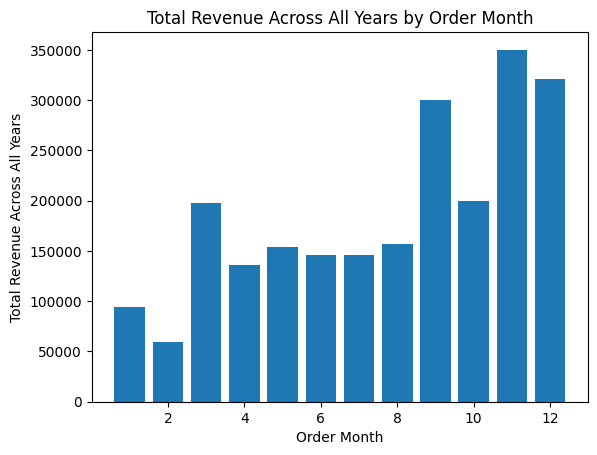

In [ ]:
plt.bar(monthly_total_revenue['Order Month'], monthly_total_revenue['Total Revenue Across All Years'])
plt.xlabel('Order Month')
plt.ylabel('Total Revenue Across All Years')
plt.title('Total Revenue Across All Years by Order Month')
plt.show()

##Task 2 — Time Series Analysis & Decomposition

- Plot the overall monthly sales trend across all 4 years

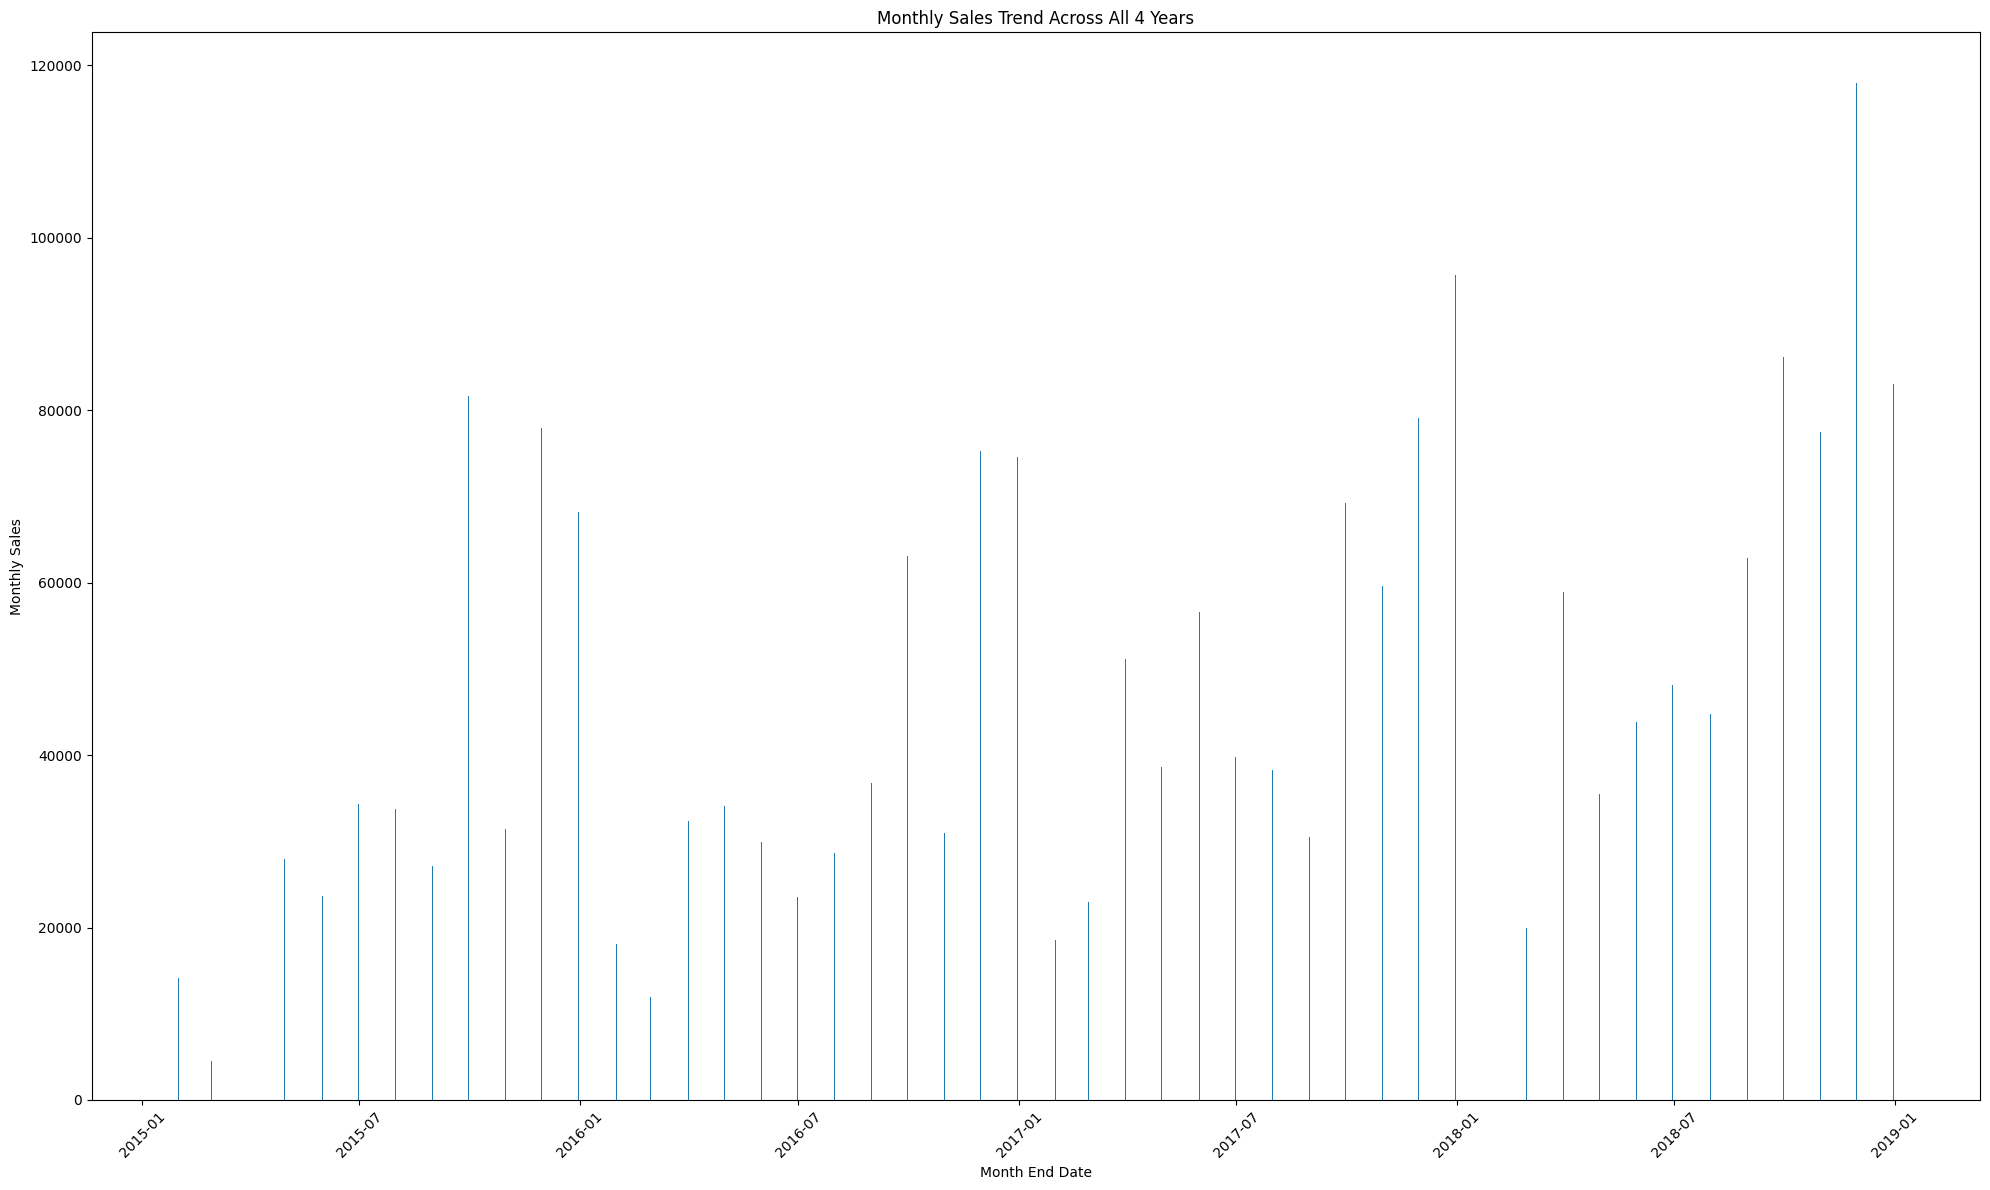

In [ ]:
plt.figure(figsize=(20, 12))
plt.bar(df_monthly_sales['Month End Date'], df_monthly_sales['Monthly Sales'])
plt.xlabel('Month End Date', )
plt.ylabel('Monthly Sales')
plt.title('Monthly Sales Trend Across All 4 Years')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
   - Trend component
   - Seasonal component
   - Residual/noise component

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set 'Month End Date' as index for decomposition
df_monthly_sales_indexed = df_monthly_sales.set_index('Month End Date')

# Apply time series decomposition
decomposition = seasonal_decompose(df_monthly_sales_indexed['Monthly Sales'], model='additive', period=12)

# Store the components
trend = decomposition.trend

print('Trend Component :')
trend

Trend Component :


,trend
Month End Date,
2015-01-31,NaN
2015-02-28,NaN
2015-03-31,NaN
2015-04-30,NaN
2015-05-31,NaN
2015-06-30,NaN
2015-07-31,40148.902783
2015-08-31,40619.434850
2015-09-30,39976.311533


In [ ]:
seasonal = decomposition.seasonal

print('Seasonal Component :')
seasonal

Seasonal Component :


,seasonal
Month End Date,
2015-01-31,-18307.338037
2015-02-28,-27368.402667
2015-03-31,1244.763035
2015-04-30,-10787.508768
2015-05-31,-4626.878630
2015-06-30,-11698.570528
2015-07-31,-9185.216915
2015-08-31,-11883.161587
2015-09-30,27676.282185


In [ ]:
residual = decomposition.resid

print('Residual Component :')
residual

Residual Component :


,resid
Month End Date,
2015-01-31,NaN
2015-02-28,NaN
2015-03-31,NaN
2015-04-30,NaN
2015-05-31,NaN
2015-06-30,NaN
2015-07-31,2817.857132
2015-08-31,-1618.736763
2015-09-30,13970.933082


- Plot all 4 components clearly on one figure

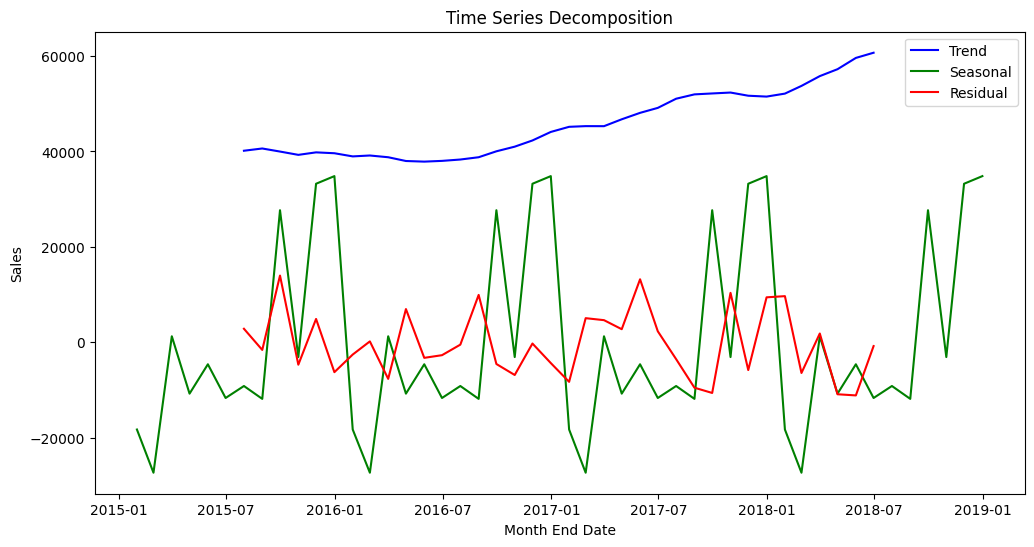

In [ ]:
# Line graph
plt.figure(figsize=(12, 6))
plt.plot(trend, label='Trend', color='blue')
plt.plot(seasonal, label='Seasonal', color='green')
plt.plot(residual, label='Residual', color='red')
plt.xlabel('Month End Date')
plt.ylabel('Sales')
plt.title('Time Series Decomposition')
plt.legend()
plt.show()

- Write 3–4 observations:
    - what does the trend tell you?

    Ans: Line graph shows that trend is increasing the sales along the years


    - Is seasonality strong or weak?

    Ans:  Seasonality is very strong which could be easily seen from the line graph as the sales are tremendously increasing in the month of October, November, December and January

    - What months show the highest residual noise?

    Ans: September'2015

In [ ]:
residual.max()

13970.93308182872

In [ ]:
residual.idxmax()

Timestamp('2015-09-30 00:00:00')

- Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you

  Ans: Stationarity means that statistical components (like mean,variance, std deviation) remains constant over time. A stationary series doesn't have a trend (it's not consistently going up or down), doesn't have seasonality (predictable repeating patterns), and its variability doesn't change over time. It basically looks the same no matter which point in time you look at it.

  Interpretation:

    - P-value (0.000278): This is the most crucial part. A common threshold for statistical significance is 0.05. Since your p-value (0.000278) is much smaller than 0.05, we reject the null hypothesis.
    - Test Statistic (-4.416137) vs. Critical Values: Your Test Statistic (-4.416137) is more negative than all the critical values (e.g., -3.577848 at 1%). This also leads us to reject the null hypothesis.

   Conclusion:

   Based on these results, your Monthly Sales series is likely stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    # Interpret results
    if dftest[1] <= 0.05: # p-value <= 0.05
        print('Series is likely stationary (reject H0)')
    else:
        print('Series is likely non-stationary (cannot reject H0)')

print('ADF Test for Original Monthly Sales Series:')
check_stationarity(df_monthly_sales_indexed['Monthly Sales'].dropna())

ADF Test for Original Monthly Sales Series:
Results of Dickey-Fuller Test:
Test Statistic                 -4.416137
p-value                         0.000278
#Lags Used                      0.000000
Number of Observations Used    47.000000
Critical Value (1%)            -3.577848
Critical Value (5%)            -2.925338
Critical Value (10%)           -2.600774
dtype: float64
Series is likely stationary (reject H0)


- Apply differencing if the series is non-stationary and re-test

     **Ans:** No need of differencing as the data is stationary

In [ ]:
# Apply first-order differencing to the 'Monthly Sales' series
#df_monthly_sales_indexed['Monthly Sales Differenced'] = df_monthly_sales_indexed['Monthly Sales'].diff().dropna()

#rint('First-Order Differenced Monthly Sales (first 5 rows):')
#df_monthly_sales_indexed['Monthly Sales Differenced'].head()

In [ ]:
# Re-run ADF test on the differenced series
#print('ADF Test for Differenced Monthly Sales Series:')
#check_stationarity(df_monthly_sales_indexed['Monthly Sales Differenced'].dropna())

##Task 3 — Sales Forecasting using 3 Different Models
This is the core technical task. Build, train, and compare 3 fundamentally different forecasting approaches:


###Model 1 — SARIMA (Statistical Model)

- Install statsmodels (pip install statsmodels)

In [ ]:
!pip install statsmodels
!pip install pmdarima
import statsmodels.api as sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.5 MB/s eta 0:00:00


- Fit a SARIMA model on monthly sales


In [ ]:
import pmdarima as pm

monthly_sales = df_monthly_sales_indexed['Monthly Sales']

# Run auto_arima with daily seasonality (m=12)
auto_model = pm.auto_arima(
    monthly_sales,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

# View best model details
print("Best SARIMA model:", auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1079.923, Time=1.59 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1096.560, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1076.500, Time=0.32 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1077.487, Time=0.68 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1094.708, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1089.579, Time=0.10 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1078.250, Time=0.79 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1078.452, Time=0.34 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1080.901, Time=0.57 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1079.864, Time=1.49 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1084.035, Time=0.10 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1073.635, Time=0.30 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1087.151, Time=0.12 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1075.267, Time=1.10 sec
 ARIMA(2,1,0)(1,0,1

- Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them

  **Ans:** (2,1,0) and (1,0,0,12) because this combination yielded the lowest AIC (Akaike Information Criterion) during its stepwise search. The AIC balances model fit and complexity, aiming for the best predictive power without overfitting.

In [ ]:
sarima_model = sm.tsa.SARIMAX(
    df_monthly_sales_indexed['Monthly Sales'],
    order=(2, 1, 0),  # (p, d, q)
    seasonal_order=(1, 0, 0, 12),  # (P, D, Q, m)
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


- Generate a 3-month future forecast with confidence intervals

In [ ]:
forecast_steps = 3
forecast = sarima_result.predict(start=len(df_monthly_sales_indexed), end=len(df_monthly_sales_indexed) + forecast_steps - 1).rename('Predicted Forecast')


print('3-month Forecast:')
forecast

3-month Forecast:


,Predicted Forecast
2019-01-31,65162.359729
2019-02-28,48808.256887
2019-03-31,66799.320060


In [ ]:
forecast_steps = 3

# Get the forecast object which includes confidence intervals
forecast_obj = sarima_result.get_forecast(steps=forecast_steps)

# Extract predicted values and rename the series for clarity
forecast_values = forecast_obj.predicted_mean.rename('Predicted Forecast')

# Extract confidence intervals
confidence_intervals = forecast_obj.conf_int()

# Combine forecast and confidence intervals into a single DataFrame
forecast_df = pd.DataFrame({
    'Predicted Sales': forecast_values,
    'Lower Bound (95% CI)': confidence_intervals.iloc[:, 0],
    'Upper Bound (95% CI)': confidence_intervals.iloc[:, 1]
})

print('3-month Forecast with Confidence Intervals:')
display(forecast_df)

3-month Forecast with Confidence Intervals:


,Predicted Sales,Lower Bound (95% CI),Upper Bound (95% CI)
2019-01-31,65162.359729,20224.514135,110100.205323
2019-02-28,48808.256887,2574.923974,95041.589799
2019-03-31,66799.320060,17959.212918,115639.427201


- Plot actual vs forecasted sales


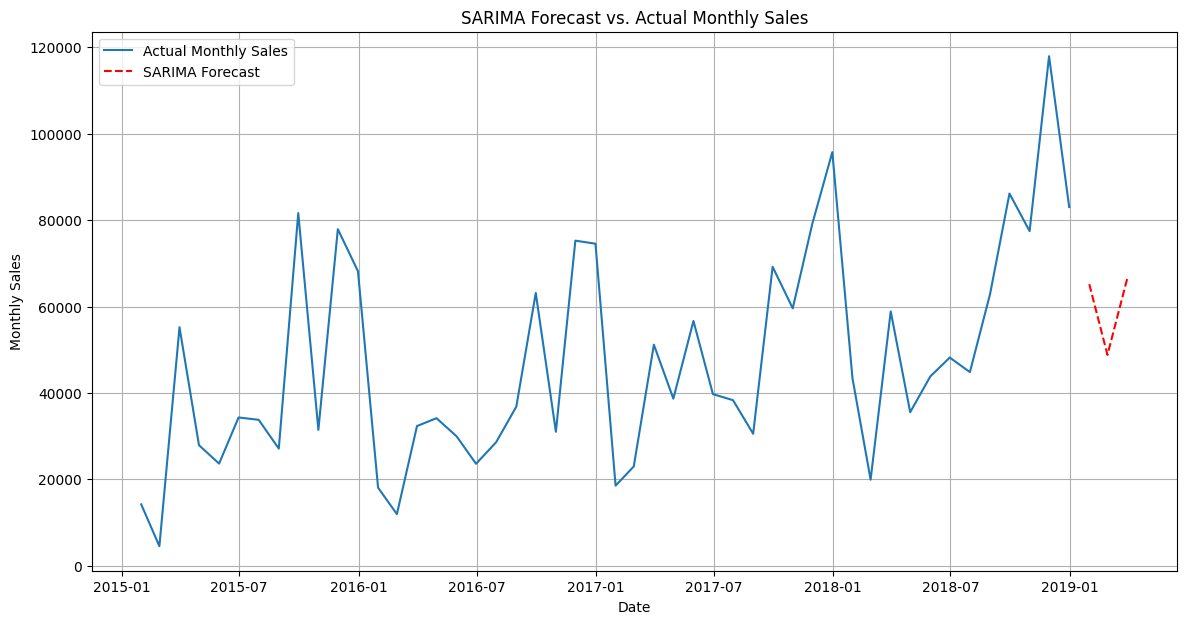

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_monthly_sales_indexed['Monthly Sales'], label='Actual Monthly Sales')
plt.plot(forecast, label='SARIMA Forecast', color='red', linestyle='--')

#Add shaded confidence intervals if available from SARIMA model
# if 'conf_int' in dir(sarima_result):
#     confidence_intervals = sarima_result.get_forecast(steps=forecast_steps).conf_int()
#     plt.fill_between(confidence_intervals.index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('SARIMA Forecast vs. Actual Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.grid(True)
plt.show()

###Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

- Install Prophet (pip install prophet)

In [ ]:
!pip install prophet

- Prepare data in Prophet's required format (ds, y columns)

In [ ]:
from prophet import Prophet

prophet_df = df_monthly_sales_indexed.reset_index()
prophet_df = prophet_df[['Month End Date', 'Monthly Sales']]
prophet_df.rename(columns={'Month End Date': 'ds', 'Monthly Sales': 'y'}, inplace=True)

#print('Prophet-ready DataFrame (first 5 rows):')
print(prophet_df.head())

          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


- Fit the model and generate a 3-month forecast

In [ ]:
# Initialize and fit the Prophet model
m = Prophet(seasonality_mode='additive') # Using additive seasonality based on decomposition
m.fit(prophet_df)

# Create a DataFrame for future predictions (3 months)
future = m.make_future_dataframe(periods=3, freq='M')

# Make predictions
prophet_forecast = m.predict(future)

print('Prophet 3-month Forecast (last 5 rows including historical data):')
prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


Prophet 3-month Forecast (last 5 rows including historical data):


,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336967,91943.532853,109952.347762
47,2018-12-31,90673.800609,81825.134637,99350.498166
48,2019-01-31,42990.532205,33570.499702,51631.313864
49,2019-02-28,31248.159925,21618.905909,40579.430183
50,2019-03-31,81267.007775,72006.936708,90676.030802


In [ ]:
prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)

avg_sales = prophet_forecast['yhat'].tail(3).mean()

average_row = pd.DataFrame({
    'ds': ['Average'],
    'yhat': [round(avg_sales, 2)],
    'yhat_lower': [None],
    'yhat_upper': [None]
})

forecast_with_avg = pd.concat([prophet_forecast, average_row], ignore_index=True)

print('Prophet 3-month Forecast with Average (last 3 rows):')
forecast_with_avg[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(4)

Prophet 3-month Forecast with Average (last 3 rows):


/tmp/ipykernel_2548/2780389220.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  forecast_with_avg = pd.concat([prophet_forecast, average_row], ignore_index=True)


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31 00:00:00,42990.532205,33570.499702,51631.313864
49,2019-02-28 00:00:00,31248.159925,21618.905909,40579.430183
50,2019-03-31 00:00:00,81267.007775,72006.936708,90676.030802
51,Average,51835.230000,NaN,NaN


- Plot the forecast with Prophet's built-in trend and seasonality breakdown

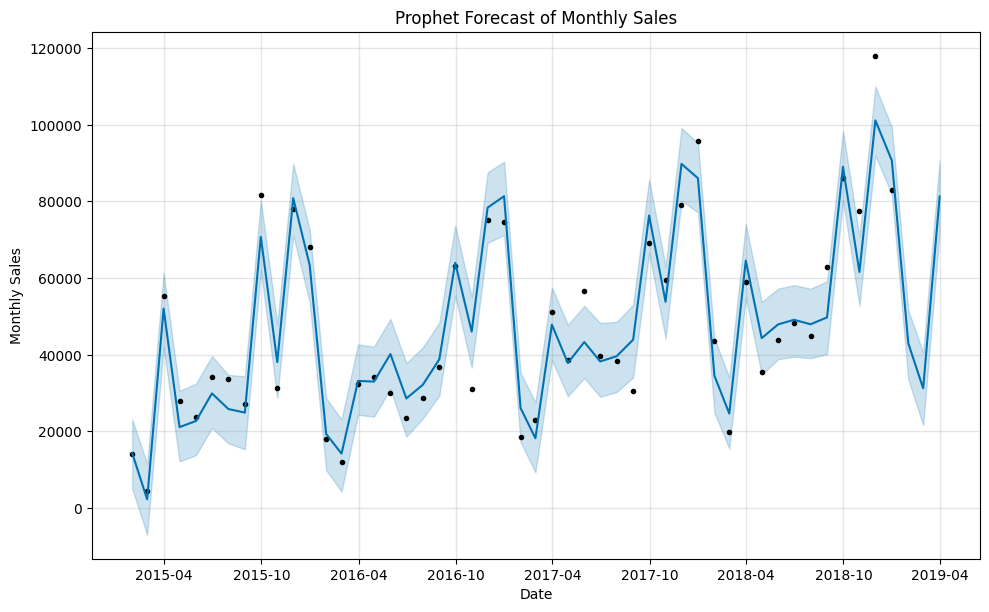

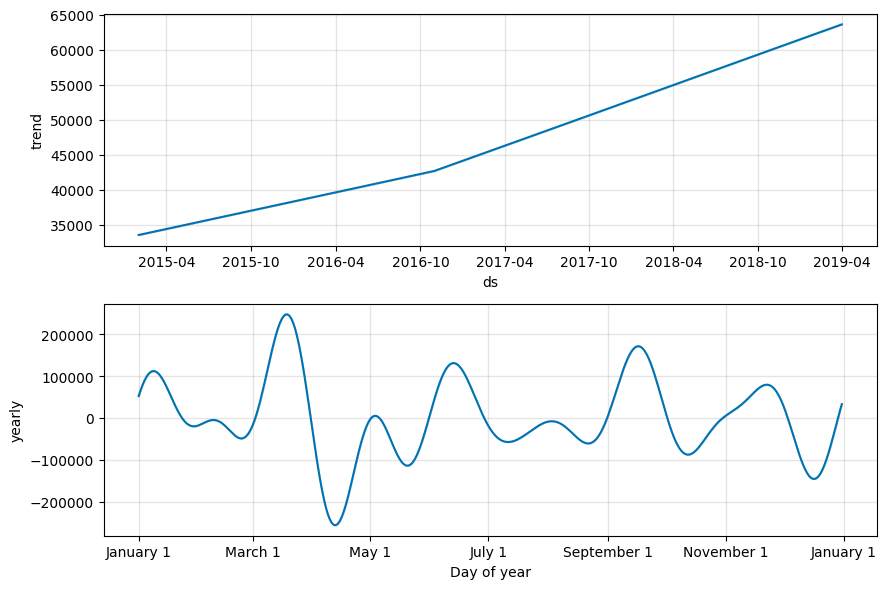

In [ ]:
fig1 = m.plot(prophet_forecast)
plt.title('Prophet Forecast of Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.show()

fig2 = m.plot_components(prophet_forecast)
plt.show()

- Extract and interpret the weekly and yearly seasonality components

In [ ]:
print('Prophet Yearly Seasonality:')
print(m.seasonalities['yearly'])

print('\nProphet Weekly Seasonality (if enabled):')
# Prophet automatically disables weekly seasonality for monthly data, as noted in previous stderr
# If it were enabled, you would access it similarly:
# print(m.seasonalities['weekly'])

Prophet Yearly Seasonality:
{'period': 365.25, 'fourier_order': 10, 'prior_scale': 10.0, 'mode': 'additive', 'condition_name': None}

Prophet Weekly Seasonality (if enabled):


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
actual = np.array(monthly_sales[-3:])
prop_preds = np.array(forecast_with_avg['yhat'][0:3])
print(mean_absolute_error(actual,prop_preds))
print(mean_absolute_percentage_error(actual,prop_preds))
print(root_mean_squared_error(actual,prop_preds))
print(forecast_with_avg['yhat'][0])

69935.49152332105
0.7231438398261377
78152.2908835912
14300.78862985962


###Model 3 — XGBoost for Time Series (ML-based Approach)

- Convert the time series into a supervised ML problem using lag features:
  - Lag 1 (sales from 1 month ago)
  - Lag 2 (sales from 2 months ago)
  - Lag 3 (sales from 3 months ago)
  - Rolling mean (3-month moving average)
  - Month, Quarter, Season as features

In [ ]:
# Create a copy of the monthly sales data
df_ml = df_monthly_sales_indexed[['Monthly Sales']].copy()
df_ml = df_ml.reset_index()
df_ml.columns = ['ds', 'y']

# Create lag features
for i in range(1, 4): # Lag 1, 2, 3
    df_ml[f'lag_{i}'] = df_ml['y'].shift(i)

# Create rolling mean feature
df_ml['rolling_mean_3'] = df_ml['y'].rolling(window=3).mean().shift(1)

# Extract time-based features
df_ml['month'] = df_ml['ds'].dt.month
df_ml['quarter'] = df_ml['ds'].dt.quarter
def get_season_ml(month):
    if month in [12, 1, 2]:
        return 0 # Winter
    elif month in [3, 4, 5]:
        return 1 # Spring
    elif month in [6, 7, 8]:
        return 2 # Summer
    else:
        return 3 # Autumn
df_ml['season'] = df_ml['month'].apply(get_season_ml)

# Drop rows with NaN values created by lagging and rolling features
df_ml.dropna(inplace=True)

print('Features for XGBoost (first 5 rows):')
df_ml.head()

Features for XGBoost (first 5 rows):


,ds,y,lag_1,lag_2,lag_3,rolling_mean_3,month,quarter,season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,2


- Train XGBoost Regressor on these features

In [ ]:
# Define features (X) and target (y)
X = df_ml[['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter', 'season']]
y = df_ml['y']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((36, 7), (9, 7), (36,), (9,))

In [ ]:
import xgboost as xgb

# Initialize and train XGBoost Regressor model
model_xgb = xgb.XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3, early_stopping_rounds=50)
model_xgb.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_test,y_test)], verbose=50)

[0]	validation_0-rmse:22150.07442	validation_1-rmse:29565.67439
[50]	validation_0-rmse:8828.86729	validation_1-rmse:18106.13820
[100]	validation_0-rmse:4917.82185	validation_1-rmse:16562.24819
[150]	validation_0-rmse:3409.05470	validation_1-rmse:16003.61454
[200]	validation_0-rmse:2400.55807	validation_1-rmse:15650.29926
[250]	validation_0-rmse:1798.11968	validation_1-rmse:15584.11657
[300]	validation_0-rmse:1378.84784	validation_1-rmse:15555.21626
[350]	validation_0-rmse:1001.35338	validation_1-rmse:15547.51317
[374]	validation_0-rmse:873.85407	validation_1-rmse:15532.52645


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

- Predict the next 3 months

In [ ]:
last_historical_date = monthly_sales.index[-1]
current_sales_history = list(monthly_sales.values[-3:]) # Keeps track of the last 3 actual months

# 2. Setup storage for our future predictions
future_dates = pd.date_range(start=last_historical_date, periods=4, freq='ME')[1:]
predictions = []

# 3. Run the Recursive Loop for exactly 3 months
for i, estimate_date in enumerate(future_dates):
    # Extract calendar features dynamically based on the target month
    m = estimate_date.month
    q = (m - 1) // 3 + 1

    # Season mapping
    if m in [12, 1, 2]: s = 0
    elif m in [3, 4, 5]: s = 1
    elif m in [6, 7, 8]: s = 2
    else: s = 3

    # Reconstruct the exact feature row layout your model was trained on
    lag1 = current_sales_history[-1]
    lag2 = current_sales_history[-2]
    lag3 = current_sales_history[-3]
    rolling_3m = np.mean([lag1, lag2, lag3])

    # Create the X input array
    X_next = pd.DataFrame([{
        'lag_1': lag1,
        'lag_2': lag2,
        'lag_3': lag3,
        'rolling_mean_3': rolling_3m,
        'month': m,
        'quarter': q,
        'season': s
    }])

    # Predict the next month
    pred = model_xgb.predict(X_next)[0]
    predictions.append(pred)

    # CRITICAL: Append the new prediction into our history so the NEXT loop can use it as a lag!
    current_sales_history.append(pred)

# 4. Build the final clean output DataFrame
xgboost_forecast = pd.DataFrame({
    'Date': future_dates,
    'XGBoost_Predicted_Sales': predictions
}).set_index('Date')

print(xgboost_forecast)

            XGBoost_Predicted_Sales
Date                               
2019-01-31             43917.550781
2019-02-28             21472.242188
2019-03-31             44302.378906


- Plot actual vs predicted

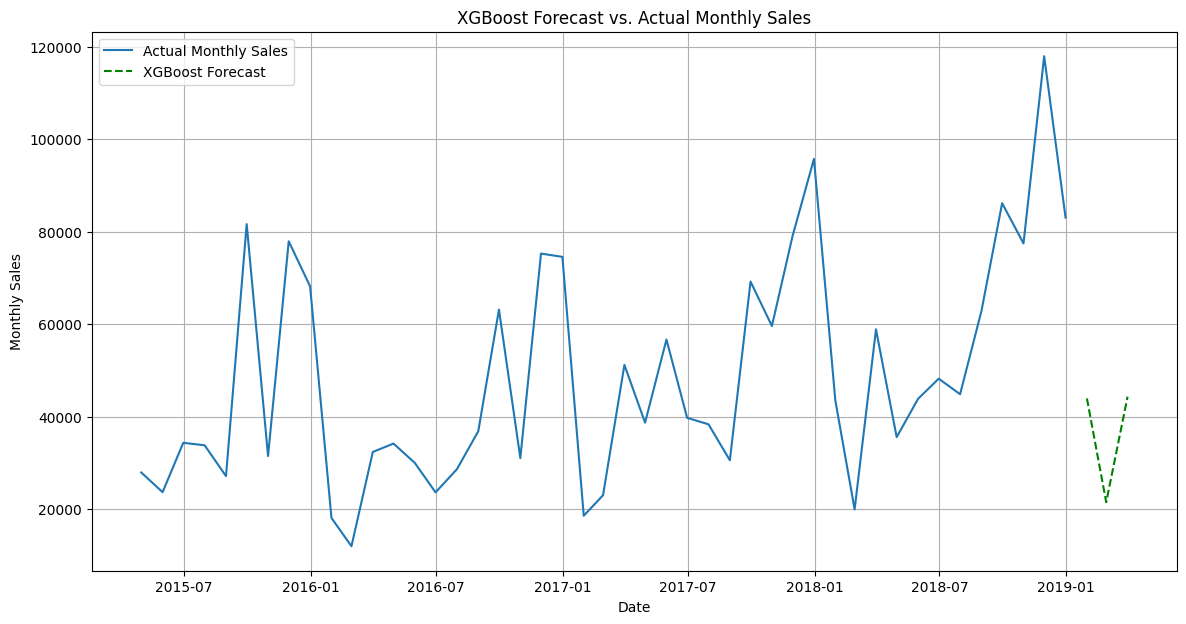

In [ ]:
# Plot actual vs. predicted sales for XGBoost
plt.figure(figsize=(14, 7))
plt.plot(df_ml['ds'], df_ml['y'], label='Actual Monthly Sales')
plt.plot(xgboost_forecast.index, xgboost_forecast['XGBoost_Predicted_Sales'], label='XGBoost Forecast', color='green', linestyle='--')
plt.title('XGBoost Forecast vs. Actual Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.grid(True)
plt.show()

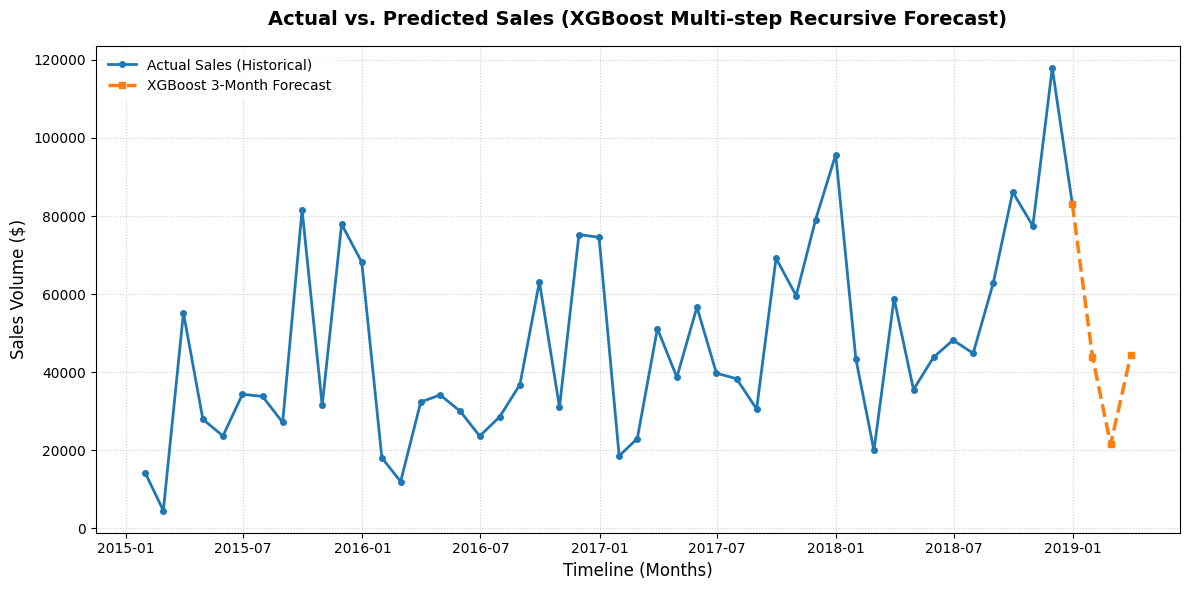

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup the plotting canvas
plt.figure(figsize=(12, 6))

# 2. Plot the historical actual data (Observed sales)
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label='Actual Sales (Historical)',
    color='#1f77b4',
    linewidth=2,
    marker='o',
    markersize=4
)

# 3. Connect the forecast seamlessly to the last historical point
# We create a small 1-row DataFrame of the last actual point to bridge the visual gap
bridge_df = pd.DataFrame(
    {'XGBoost_Predicted_Sales': [monthly_sales.values[-1]]},
    index=[monthly_sales.index[-1]]
)

# Combine the bridge point with your future predictions dataframe
full_forecast = pd.concat([bridge_df, xgboost_forecast])

# 4. Plot the predicted data line
plt.plot(
    full_forecast.index,
    full_forecast['XGBoost_Predicted_Sales'],
    label='XGBoost 3-Month Forecast',
    color='#ff7f0e',
    linewidth=2.5,
    linestyle='--',
    marker='s',
    markersize=5
)

# 5. Polish the chart aesthetics for business presentations
plt.title("Actual vs. Predicted Sales (XGBoost Multi-step Recursive Forecast)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline (Months)", fontsize=12)
plt.ylabel("Sales Volume ($)", fontsize=12)

# Format the grid lines cleanly
plt.grid(True, linestyle=':', alpha=0.6)

# Place the legend in an empty location automatically
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# Clean layout spacing
plt.tight_layout()
plt.show()


###Model Comparison Table (Required)


- Create a clear comparison table in your notebook:

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

# actual historical sales (for comparison purposes within this table)
# These are the actual sales for the last 3 months of the historical data (Oct, Nov, Dec 2018).
# Comparing future forecasts against these values is not a standard evaluation for future prediction accuracy.
actual_last_3_months = np.array(monthly_sales[-3:])

# future predictions or forecasts from all three models
# Prophet's future predictions are in the 'yhat' column of prophet_forecast. We take the last 3 entries.
prop_preds_future = np.array(prophet_forecast['yhat'].tail(3))
# XGBoost's future predictions are in 'XGBoost_Predicted_Sales' column of xgboost_forecast.
xgboost_preds_future = np.array(xgboost_forecast['XGBoost_Predicted_Sales'])
# SARIMA's future predictions are in 'Predicted Sales' column of forecast_df.
sarima_preds_future = np.array(forecast_df['Predicted Sales'])

# models column
models = ['SARIMA', 'Prophet', 'XGBoost']

# Calculate metrics comparing future forecasts against the last 3 historical actuals.
# This is a non-standard evaluation for future forecast performance.

sarima_mae = mean_absolute_error(actual_last_3_months, sarima_preds_future)
prophet_mae = mean_absolute_error(actual_last_3_months, prop_preds_future)
xgboost_mae = mean_absolute_error(actual_last_3_months, xgboost_preds_future)

sarima_mape = mean_absolute_percentage_error(actual_last_3_months, sarima_preds_future) * 100
prophet_mape = mean_absolute_percentage_error(actual_last_3_months, prop_preds_future) * 100
xgboost_mape = mean_absolute_percentage_error(actual_last_3_months, xgboost_preds_future) * 100

sarima_rmse = root_mean_squared_error(actual_last_3_months, sarima_preds_future)
prophet_rmse = root_mean_squared_error(actual_last_3_months, prop_preds_future)
xgboost_rmse = root_mean_squared_error(actual_last_3_months, xgboost_preds_future)


# metric dictionary
metric_dict = {
    'MAE': [sarima_mae, prophet_mae, xgboost_mae],
    'MAPE': [sarima_mape, prophet_mape, xgboost_mape],
    'RMSE': [sarima_rmse, prophet_rmse, xgboost_rmse],
    'Month 1 Forecast': [sarima_preds_future[0], prop_preds_future[0], xgboost_preds_future[0]],
    'Month 2 Forecast': [sarima_preds_future[1], prop_preds_future[1], xgboost_preds_future[1]],
    'Month 3 Forecast': [sarima_preds_future[2], prop_preds_future[2], xgboost_preds_future[2]],
    'Models': models
}

# rounding off to two decimals for each value
metric_dict_rounded = {key: np.round(value, 2) if key != 'Models' else value for key, value in metric_dict.items()}

# metrics dataframe
metric_df = pd.DataFrame(metric_dict_rounded)
metric_df.set_index('Models', inplace=True)
metric_df

,MAE,MAPE,RMSE,Month 1 Forecast,Month 2 Forecast,Month 3 Forecast
Models,,,,,,
SARIMA,32548.91,31.34,41606.61,65162.36,48808.26,66799.32
Prophet,40970.33,40.04,53868.95,42990.53,31248.16,81267.01
XGBoost,56241.50,57.24,63060.37,43917.55,21472.24,44302.38


- State clearly which model you would recommend for production use and why — based on numbers, not preference.

**Ans:** SARIMA is the best model as it has lowest MAE,MAPE,RMSE

##Task 4 — Product Category & Region Level Forecasting
- Repeat the best performing model i.e., **SARIMA** (from Task 3) separately for each of the following segments:
  - Furniture category sales
  - Technology category sales
  - Office Supplies category sales
  - West region sales
  - East region sales


In [ ]:
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

def forecast_sarima_for_segment(segment_df, segment_name, forecast_steps=3):
    # Aggregate to monthly sales for the segment
    segment_monthly_sales = segment_df.set_index('Order Date').resample('ME')['Sales'].sum().rename(f'{segment_name} Monthly Sales')

    # Fit SARIMA model (using previously determined best parameters)
    try:
        # Ensure the series has enough non-null data for SARIMA
        if len(segment_monthly_sales.dropna()) < 24: # Minimum 2 years for seasonal (m=12)
            print(f"Warning: Not enough data for SARIMA for {segment_name}. Skipping.")
            return None

        sarima_model = SARIMAX(
            segment_monthly_sales,
            order=(2, 1, 0),  # (p, d, q)
            seasonal_order=(1, 0, 0, 12),  # (P, D, Q, m)
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        sarima_result = sarima_model.fit(disp=False) # disp=False to suppress convergence messages

        # Generate forecast
        forecast_obj = sarima_result.get_forecast(steps=forecast_steps)
        forecast_values = forecast_obj.predicted_mean.rename(f'{segment_name} Forecast')
        return forecast_values
    except Exception as e:
        print(f"Error fitting SARIMA for {segment_name}: {e}")
        return None


# --- Prepare data and forecast for Product Categories ---
categories = ['Furniture', 'Technology', 'Office Supplies']
category_forecasts = {}
for category in categories:
    category_df = df[df['Category'] == category]
    forecast = forecast_sarima_for_segment(category_df, f'{category} Sales')
    if forecast is not None:
        category_forecasts[category] = forecast


# --- Prepare data and forecast for Regions ---
regions = ['West', 'East']
region_forecasts = {}
for region in regions:
    region_df = df[df['Region'] == region]
    forecast = forecast_sarima_for_segment(region_df, f'{region} Sales')
    if forecast is not None:
        region_forecasts[region] = forecast


print("Category Forecasts:")
for cat, f in category_forecasts.items():
    display(pd.DataFrame({cat: f}))

print("\nRegion Forecasts:")
for reg, f in region_forecasts.items():
    display(pd.DataFrame({reg: f}))


Category Forecasts:


,Furniture
2019-01-31,11600.955561
2019-02-28,10967.018744
2019-03-31,11731.023860


,Technology
2019-01-31,29071.199577
2019-02-28,27583.634246
2019-03-31,34239.164738


,Office Supplies
2019-01-31,24584.179692
2019-02-28,21435.631115
2019-03-31,22532.786100



Region Forecasts:


,West
2019-01-31,19717.913972
2019-02-28,18725.377659
2019-03-31,28904.192106


,East
2019-01-31,21387.615093
2019-02-28,10940.227352
2019-03-31,18945.116050


In [ ]:
all_forecasts = []

# Add category forecasts
for category, forecast_series in category_forecasts.items():
    all_forecasts.append(forecast_series.rename(f'{category} Forecast'))

# Add region forecasts
for region, forecast_series in region_forecasts.items():
    all_forecasts.append(forecast_series.rename(f'{region} Forecast'))

# Concatenate all forecasts into a single DataFrame
combined_forecast_df = pd.concat(all_forecasts, axis=1)
display(combined_forecast_df)

,Furniture Forecast,Technology Forecast,Office Supplies Forecast,West Forecast,East Forecast
2019-01-31,11600.955561,29071.199577,24584.179692,19717.913972,21387.615093
2019-02-28,10967.018744,27583.634246,21435.631115,18725.377659,10940.227352
2019-03-31,11731.023860,34239.164738,22532.786100,28904.192106,18945.116050


- Plot all 5 forecasts together on one comparison chart

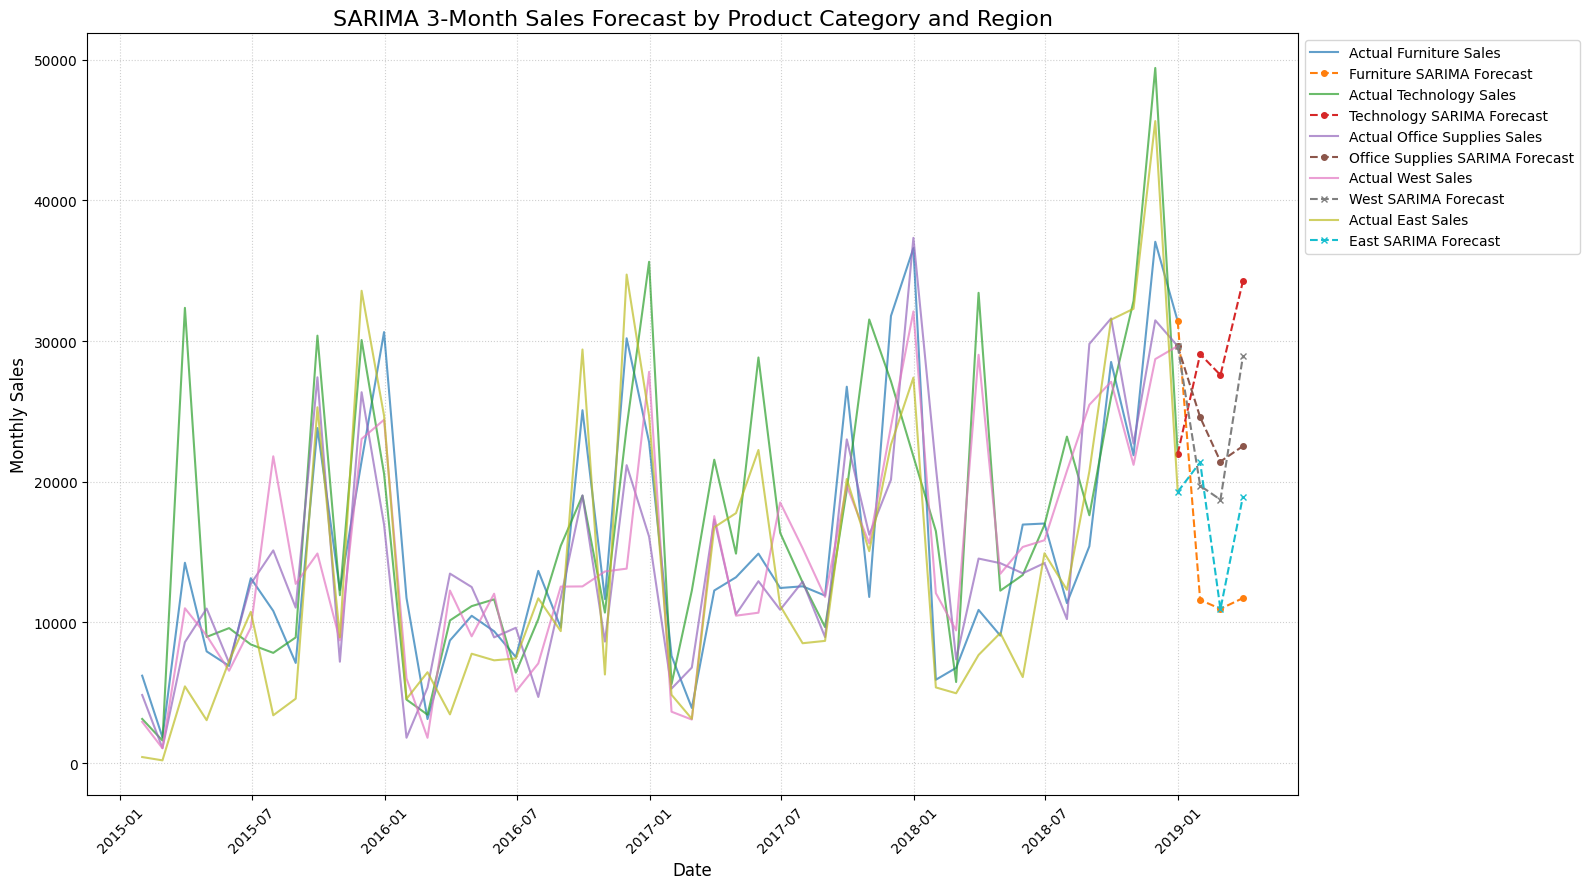

In [ ]:
plt.figure(figsize=(16, 9))

# Plot historical data for each segment and its forecast

# Categories
for category, forecast_series in category_forecasts.items():
    category_df = df[df['Category'] == category]
    segment_monthly_sales = category_df.set_index('Order Date').resample('ME')['Sales'].sum()

    # Plot historical data
    plt.plot(segment_monthly_sales.index, segment_monthly_sales.values, label=f'Actual {category} Sales', alpha=0.7)

    # Bridge the gap between historical and forecast for visual continuity
    last_historical_point = segment_monthly_sales.iloc[-1]
    last_historical_date = segment_monthly_sales.index[-1]
    bridge_forecast = pd.concat([pd.Series({last_historical_date: last_historical_point}), forecast_series])

    # Plot forecast
    plt.plot(bridge_forecast.index, bridge_forecast.values, label=f'{category} SARIMA Forecast', linestyle='--', marker='o', markersize=4)

# Regions
for region, forecast_series in region_forecasts.items():
    region_df = df[df['Region'] == region]
    segment_monthly_sales = region_df.set_index('Order Date').resample('ME')['Sales'].sum()

    # Plot historical data
    plt.plot(segment_monthly_sales.index, segment_monthly_sales.values, label=f'Actual {region} Sales', alpha=0.7)

    # Bridge the gap between historical and forecast for visual continuity
    last_historical_point = segment_monthly_sales.iloc[-1]
    last_historical_date = segment_monthly_sales.index[-1]
    bridge_forecast = pd.concat([pd.Series({last_historical_date: last_historical_point}), forecast_series])

    # Plot forecast
    plt.plot(bridge_forecast.index, bridge_forecast.values, label=f'{region} SARIMA Forecast', linestyle='--', marker='x', markersize=4)

plt.title('SARIMA 3-Month Sales Forecast by Product Category and Region', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Monthly Sales', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


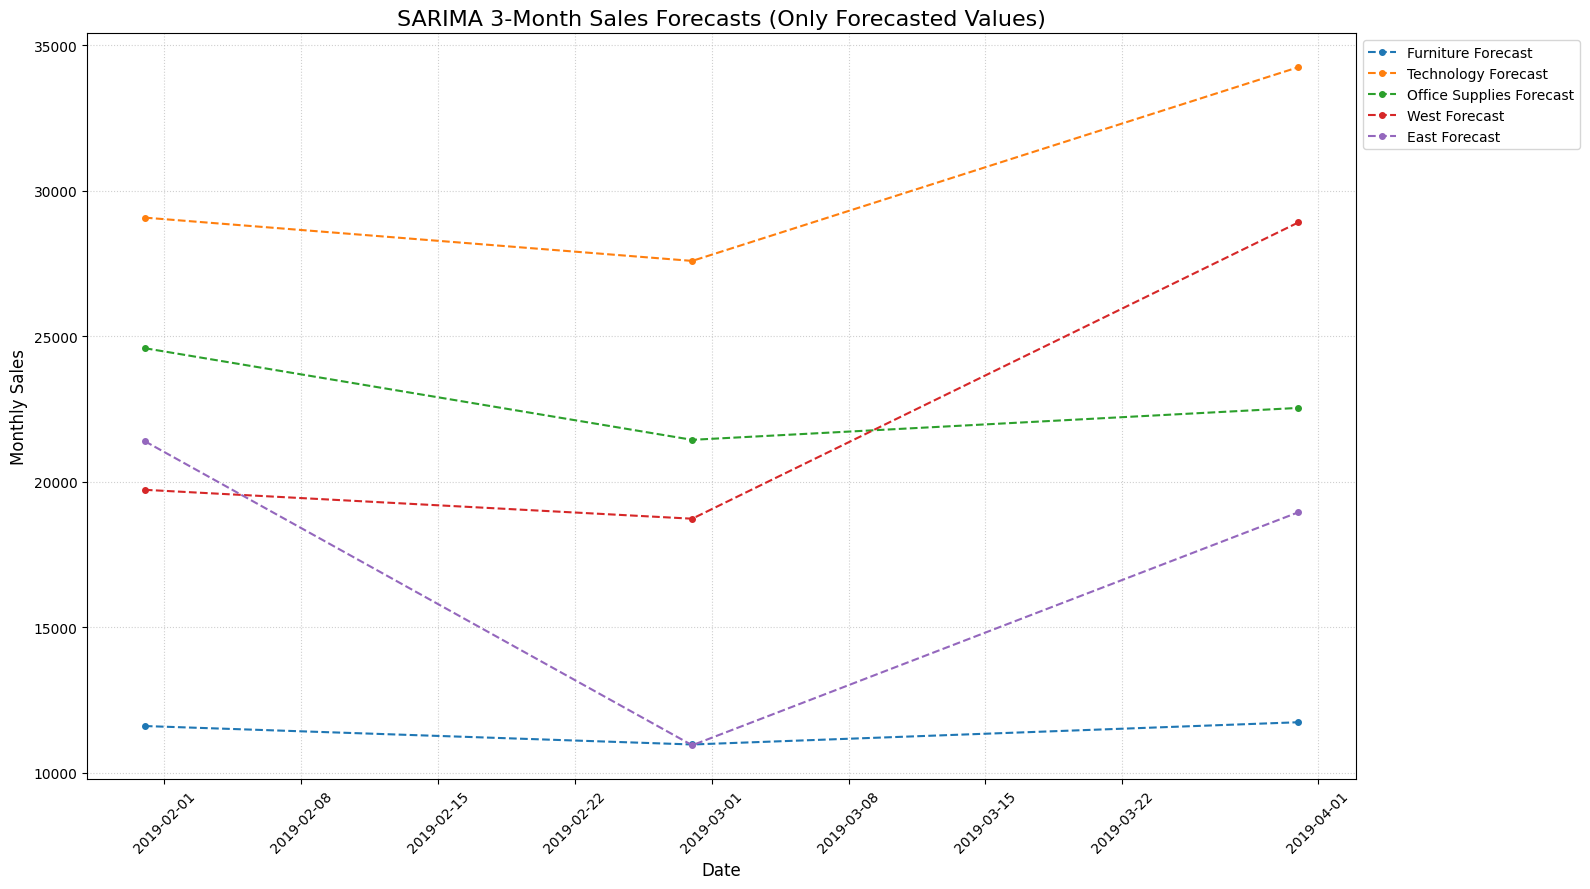

In [ ]:
plt.figure(figsize=(16, 9))

# Plot only the forecasted values
for column in combined_forecast_df.columns:
    plt.plot(combined_forecast_df.index, combined_forecast_df[column], label=column, linestyle='--', marker='o', markersize=4)

plt.title('SARIMA 3-Month Sales Forecasts (Only Forecasted Values)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Monthly Sales', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Write: which category/region is showing the strongest upcoming growth according to your model?

**Ans:** **Technology Sales** is showing the strongest upcoming growth. It has the highest forecasted sales volume overall, with a significant predicted increase in the third month (from ~27.5k to ~34.2k), indicating a strong upward trend compared to other categories and for region it is **west** region which is having the more sales

### Strongest Upcoming Growth Analysis

Based on the 3-month SARIMA forecasts:

*   **Category Sales:**
    *   **Furniture Sales Forecast:** The 3-month forecasts are 11600.96, 10967.02, and 11731.02. This category shows a slight dip in the second month but recovers.
    *   **Technology Sales Forecast:** The 3-month forecasts are 29071.20, 27583.63, and 34239.16. This category shows the highest absolute forecasted sales values and a significant increase in the third month.
    *   **Office Supplies Sales Forecast:** The 3-month forecasts are 24584.18, 21435.63, and 22532.79. This category shows moderate sales, with a slight dip then a recovery.

*   **Region Sales:**
    *   **West Region Sales Forecast:** The 3-month forecasts are 19717.91, 18725.38, and 28904.19. This region shows moderate sales with a strong recovery in the third month.
    *   **East Region Sales Forecast:** The 3-month forecasts are 21387.62, 10940.23, and 18945.12. This region shows a notable dip in the second month, followed by a recovery, but overall lower than Technology category.

*   **Conclusion:** Based on the 3-month forecast values, **Technology Sales** is showing the strongest upcoming growth. It has the highest forecasted sales volume overall, with a significant predicted increase in the third month (from ~27.5k to ~34.2k), indicating a strong upward trend compared to other categories and regions.

##Task 5 — Anomaly Detection in Sales Data


- Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern
- Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean

In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np

# Use df_weekly_sales for anomaly detection
df_weekly_sales_indexed = df_weekly_sales.set_index('Week Start Date')
weekly_sales_data = df_weekly_sales_indexed['Weekly Sales'].values.reshape(-1, 1)

# --- Isolation Forest Detection ---
# Initialize and train the Isolation Forest model
# contamination is the proportion of outliers in the dataset (e.g., 0.05 for 5% outliers)
isolation_forest_model = IsolationForest(random_state=42, contamination=0.05) # Adjust contamination as needed
isolation_forest_model.fit(weekly_sales_data)

# Predict anomalies (-1 for outliers, 1 for inliers)
df_weekly_sales_indexed['isolation_forest_anomaly'] = isolation_forest_model.predict(weekly_sales_data)

# --- Z-Score Based Detection ---
window_size = 4  # e.g., 4-week rolling window
df_weekly_sales_indexed['rolling_mean'] = df_weekly_sales_indexed['Weekly Sales'].rolling(window=window_size).mean()
df_weekly_sales_indexed['rolling_std'] = df_weekly_sales_indexed['Weekly Sales'].rolling(window=window_size).std()

# Define threshold (e.g., 2 standard deviations)
std_threshold = 2
df_weekly_sales_indexed['z_score_anomaly'] = (
    (df_weekly_sales_indexed['Weekly Sales'] > df_weekly_sales_indexed['rolling_mean'] + std_threshold * df_weekly_sales_indexed['rolling_std']) |
    (df_weekly_sales_indexed['Weekly Sales'] < df_weekly_sales_indexed['rolling_mean'] - std_threshold * df_weekly_sales_indexed['rolling_std'])
).astype(int)
# Convert True/False to 1/0 for easier comparison, and then to -1 for anomalies, 1 for normal
df_weekly_sales_indexed['z_score_anomaly'] = df_weekly_sales_indexed['z_score_anomaly'].replace({0: 1, 1: -1})


print("Isolation Forest Anomalies (first 5 rows with anomaly flags):")
display(df_weekly_sales_indexed[df_weekly_sales_indexed['isolation_forest_anomaly'] == -1].head())

print("\nZ-Score Anomalies (first 5 rows with anomaly flags):")
display(df_weekly_sales_indexed[df_weekly_sales_indexed['z_score_anomaly'] == -1].head())


Isolation Forest Anomalies (first 5 rows with anomaly flags):


,Weekly Sales,isolation_forest_anomaly,rolling_mean,rolling_std,z_score_anomaly
Week Start Date,,,,,
2015-01-04,304.508,-1,NaN,NaN,1
2015-02-08,968.534,-1,2679.88125,1319.909656,1
2015-02-22,224.912,-1,1623.10350,1227.446277,1
2015-03-22,37703.665,-1,12040.90950,17129.486138,1
2015-07-19,1387.686,-1,3995.16800,2167.025645,1



Z-Score Anomalies (first 5 rows with anomaly flags):


,Weekly Sales,isolation_forest_anomaly,rolling_mean,rolling_std,z_score_anomaly
Week Start Date,,,,,


### Plotting Anomalies (Anamoly Based)
- Mark the anomalies on a time series plot (use a different color/marker for anomaly points)

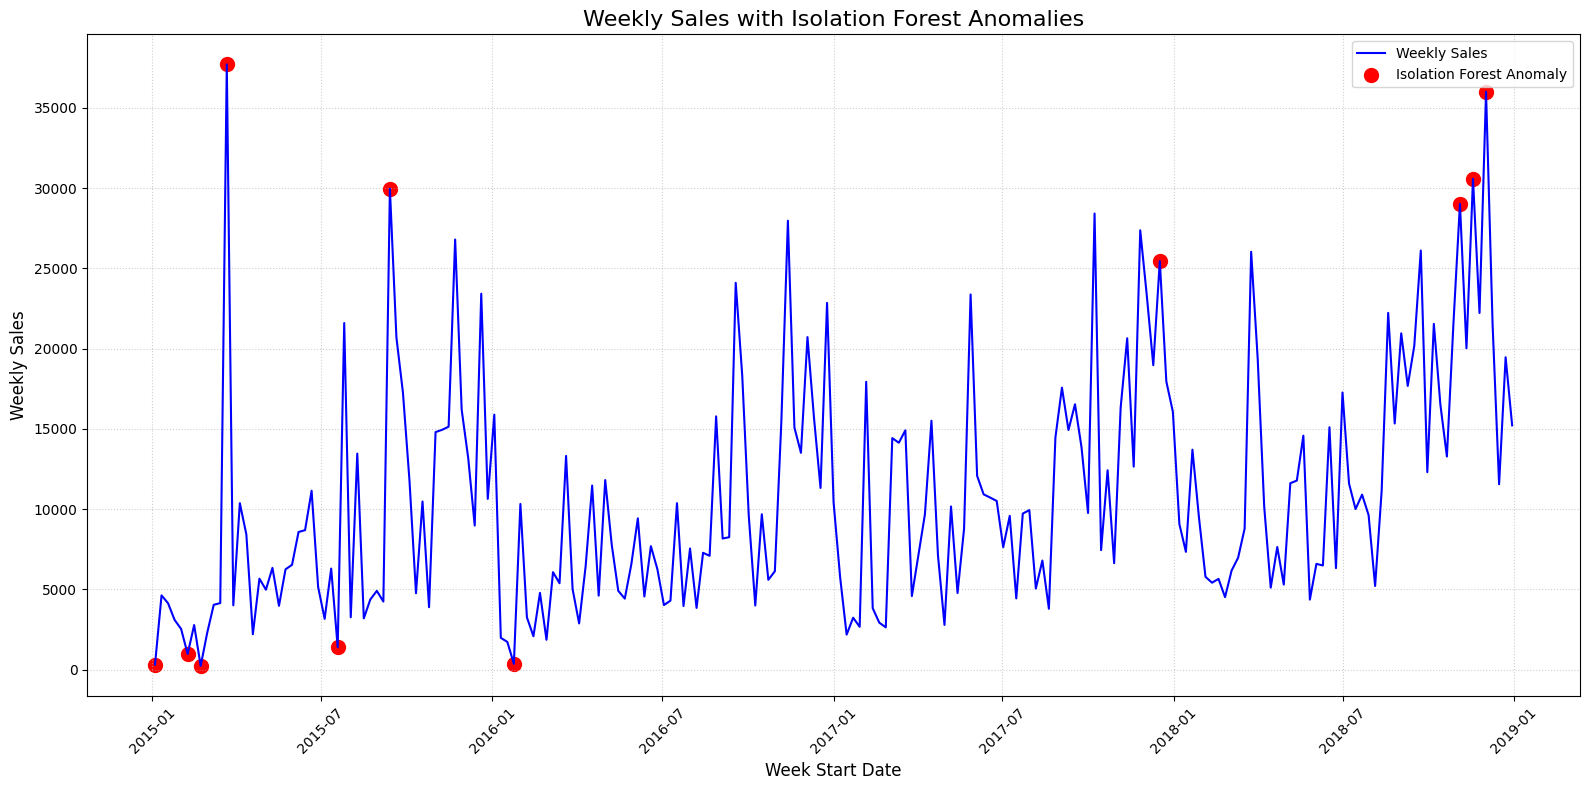

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(df_weekly_sales_indexed.index, df_weekly_sales_indexed['Weekly Sales'], label='Weekly Sales', color='blue')

# Mark Isolation Forest anomalies
anomalies_if = df_weekly_sales_indexed[df_weekly_sales_indexed['isolation_forest_anomaly'] == -1]
plt.scatter(anomalies_if.index, anomalies_if['Weekly Sales'], color='red', label='Isolation Forest Anomaly', marker='o', s=100)

plt.title('Weekly Sales with Isolation Forest Anomalies', fontsize=16)
plt.xlabel('Week Start Date', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Plotting Anomalies (Z-Score Based)

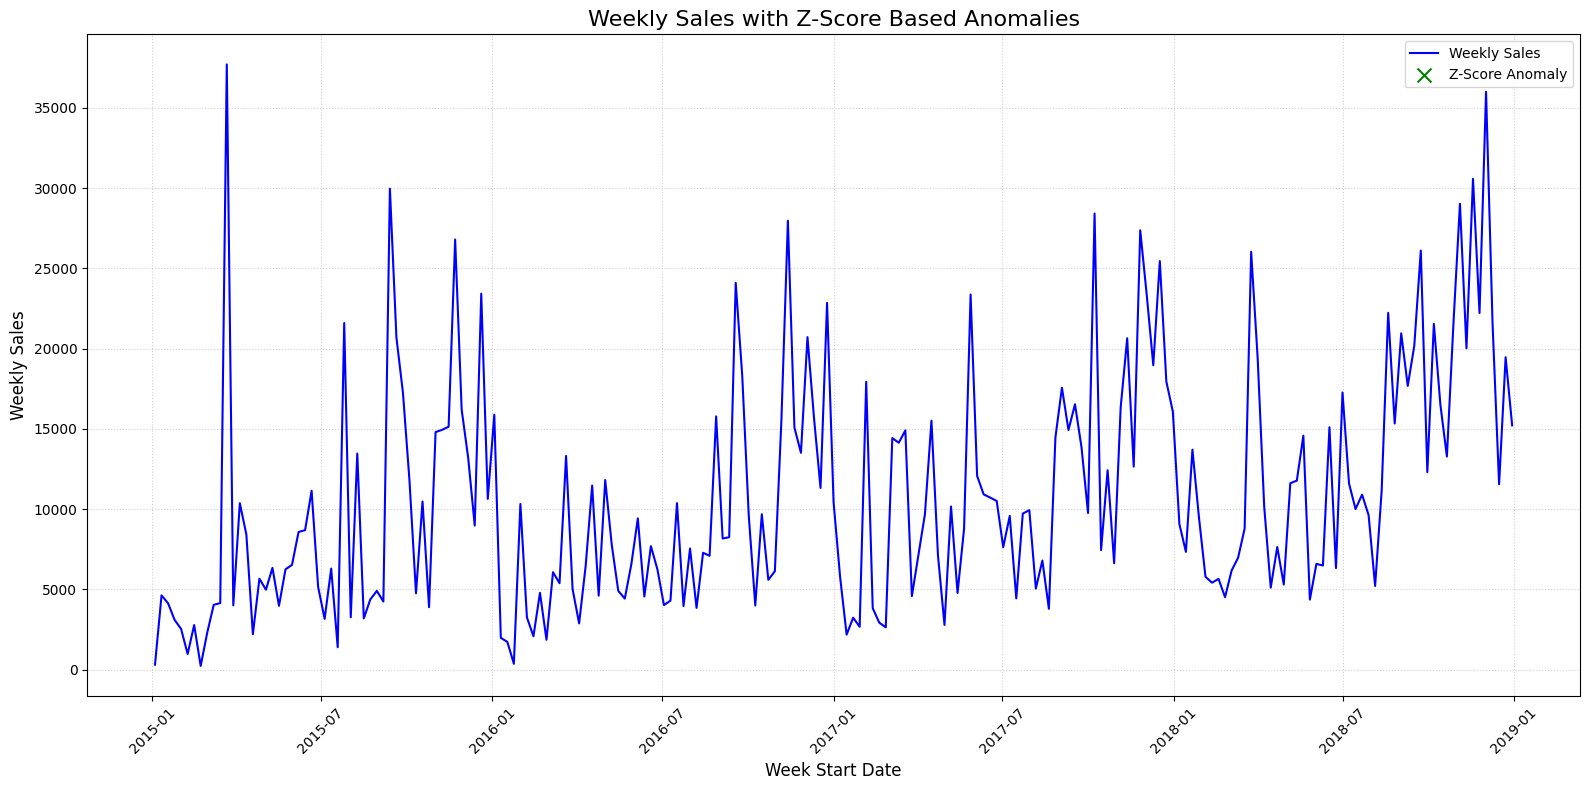

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(df_weekly_sales_indexed.index, df_weekly_sales_indexed['Weekly Sales'], label='Weekly Sales', color='blue')

# Mark Z-Score anomalies
anomalies_zs = df_weekly_sales_indexed[df_weekly_sales_indexed['z_score_anomaly'] == -1]
plt.scatter(anomalies_zs.index, anomalies_zs['Weekly Sales'], color='green', label='Z-Score Anomaly', marker='x', s=100)

plt.title('Weekly Sales with Z-Score Based Anomalies', fontsize=16)
plt.xlabel('Week Start Date', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Anomaly Comparison and Explanations
- **For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")**

*   **Isolation Forest Anomalies:**
    Isolation Forest identified several weeks as anomalous. These include:
    *   **2015-01-04 (304.51):** An unusually low sales week, possibly due to post-holiday lull or start-of-year slowness.
    *   **2015-02-08 (968.53):** Another very low sales week.
    *   **2015-02-22 (224.91):** Another very low sales week.
    *   **2015-03-22 (37703.66):** An unusually high sales week, possibly due to a major promotional event or an early seasonal surge.
    *   **2015-07-19 (1387.69):** A low sales week in the summer period.
    These anomalies suggest periods of extreme high or low sales that deviate significantly from the typical pattern learned by the Isolation Forest model.

*   **Z-Score Based Anomalies:**
    The Z-Score based detection flagged **no anomalies** in the `df_weekly_sales_indexed` dataset. This indicates that, based on a 4-week rolling mean and a 2 standard deviation threshold, no sales weeks deviated significantly enough to be considered anomalous by this method.


- **Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?**


*   **Comparison:**
    The two methods disagreed significantly: Isolation Forest found several anomalies, while Z-Score found none. This tells us a few things:
    *   **Method Sensitivity:** Isolation Forest is a non-parametric method that works by isolating observations that are few and different from the majority. It can often detect more subtle or multi-dimensional outliers. The Z-score method, on the other hand, is a statistical method that assumes a normal distribution and identifies points that are a certain number of standard deviations away from the mean. It's often more sensitive to magnitude and local deviations.
    *   **Data Characteristics:** The weekly sales data might not strictly follow a normal distribution, or its deviations from the rolling mean might not exceed the 2-standard-deviation threshold, even for visibly low or high points. The `rolling_std` might be large enough to encompass these variations within 2 standard deviations, or the `window_size` (4 weeks) might be too short to capture the overall pattern effectively for Z-score calculation.
    *   **Definition of Anomaly:** What constitutes an "anomaly" can differ between algorithms. Isolation Forest identified extreme values relative to the entire dataset's structure, while Z-score looked for extreme deviations from a very recent rolling average, which might have been too adaptive to capture the outliers identified by Isolation Forest.

##Task 6 — Product Demand Segmentation using Clustering

- Aggregate data at the product sub-category level with features like:
  - Total sales volume
  - Sales growth rate (year-over-year)
  - Sales volatility (standard deviation of monthly sales)
  - Average order value
- Apply K-Means Clustering to segment products into demand groups

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

# --- 1. Aggregate data at the product sub-category level with features ---

# Ensure 'Order Date' is datetime and sort the DataFrame for time-based calculations
df['Order Date'] = pd.to_datetime(df['Order Date'])
df_sorted = df.sort_values(by=['Sub-Category', 'Order Date'])

# Group by Sub-Category to calculate features
sub_category_data = df_sorted.groupby('Sub-Category').agg(
    total_sales_volume=('Sales', 'sum'),
    total_orders=('Order ID', 'nunique'), # Count unique Order IDs for average order value
    first_order_date=('Order Date', 'min'),
    last_order_date=('Order Date', 'max')
).reset_index()

# Calculate sales volatility (standard deviation of monthly sales)
monthly_sales_by_subcategory = df_sorted.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().unstack(fill_value=0)
sub_category_data['sales_volatility'] = monthly_sales_by_subcategory.std(axis=1)

# Calculate Sales growth rate (year-over-year) - This is a bit more complex and will be approximated for simplicity.
# For a proper YoY growth, we'd need sales for two consecutive full years for each sub-category.
# Here, we'll calculate the simple growth rate from the earliest to the latest available sales period.
# A more robust approach would be to calculate annual sales and then YoY growth.

# For simplicity, let's calculate the growth from the first year to the last year available for each sub-category
# This assumes at least two years of data for meaningful growth calculation.

def calculate_approx_growth(sub_cat_df):
    sales_by_year = sub_cat_df.groupby(sub_cat_df['Order Date'].dt.year)['Sales'].sum()
    if len(sales_by_year) < 2:
        return np.nan # Not enough data for growth

    # Growth from first available year to last available year
    first_year_sales = sales_by_year.iloc[0]
    last_year_sales = sales_by_year.iloc[-1]

    if first_year_sales == 0:
        return 0 # Avoid division by zero, assume no growth if no initial sales
    return (last_year_sales - first_year_sales) / first_year_sales

# Apply the growth rate calculation
sub_category_data['sales_growth_rate'] = df_sorted.groupby('Sub-Category').apply(calculate_approx_growth)

# Calculate Average order value
sub_category_data['average_order_value'] = sub_category_data['total_sales_volume'] / sub_category_data['total_orders']

# Clean up and select features for clustering
clustering_features = sub_category_data[['total_sales_volume', 'sales_growth_rate', 'sales_volatility', 'average_order_value']].copy()

# Handle NaNs from growth rate or volatility calculations (e.g., for sub-categories with insufficient data)
clustering_features.fillna(0, inplace=True) # Replace NaN with 0, or consider dropping rows if appropriate

print("Aggregated Features for Clustering (first 5 sub-categories):")
display(clustering_features.head())

# --- 2. Feature Scaling ---
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)
scaled_features_df = pd.DataFrame(scaled_features, columns=clustering_features.columns, index=clustering_features.index)

print("\nScaled Features (first 5 sub-categories):")
display(scaled_features_df.head())


Aggregated Features for Clustering (first 5 sub-categories):


/tmp/ipykernel_2548/3511893684.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_category_data['sales_growth_rate'] = df_sorted.groupby('Sub-Category').apply(calculate_approx_growth)


,total_sales_volume,sales_growth_rate,sales_volatility,average_order_value
0,164186.7000,0.0,0.0,233.884188
1,104618.4030,0.0,0.0,235.627034
2,26705.4100,0.0,0.0,37.090847
3,200028.7850,0.0,0.0,154.940964
4,113813.1987,0.0,0.0,512.672066



Scaled Features (first 5 sub-categories):


,total_sales_volume,sales_growth_rate,sales_volatility,average_order_value
0,0.315986,0.0,0.0,-0.357527
1,-0.288176,0.0,0.0,-0.354572
2,-1.078397,0.0,0.0,-0.691204
3,0.679509,0.0,0.0,-0.491381
4,-0.194919,0.0,0.0,0.115176


- Use the Elbow Method to find the optimal number of clusters

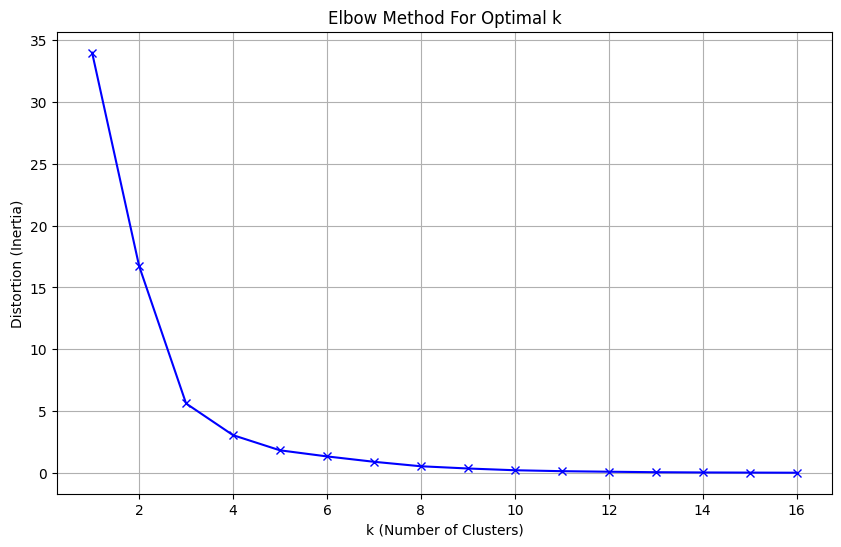


Based on the elbow plot, choose an optimal k where the rate of decrease in distortion sharply changes.
Example: Choosing optimal k = 4


In [ ]:
distortions = []
K = range(1, len(scaled_features_df))
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeanModel.fit(scaled_features_df)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Distortion (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

print("\nBased on the elbow plot, choose an optimal k where the rate of decrease in distortion sharply changes.")
optimal_k = 4 # This is an example, you would determine this visually from the plot
print(f"Example: Choosing optimal k = {optimal_k}")


- Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)

### K-Means Clustering and PCA for Visualization

Cluster sizes for optimal k=4:


,count
cluster,
0,8
1,5
3,2
2,2


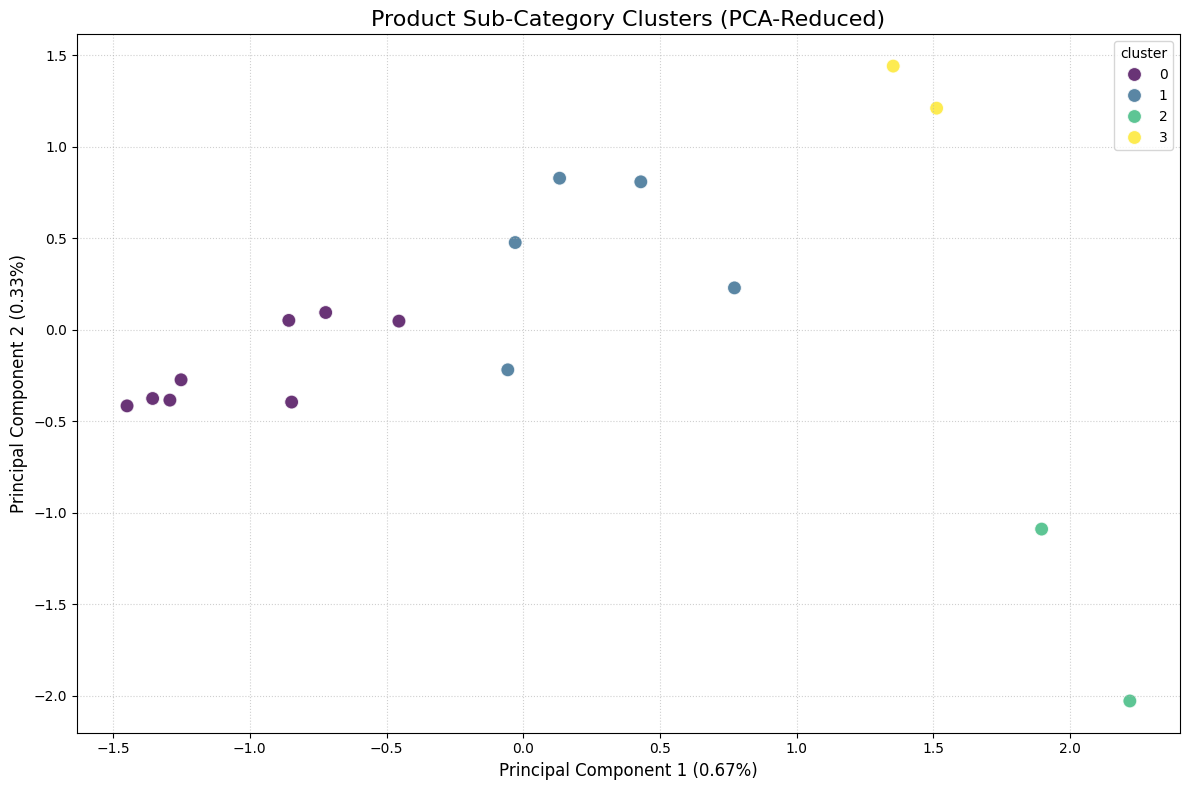


Cluster Centers (in scaled feature space):


,total_sales_volume,sales_growth_rate,sales_volatility,average_order_value
0,-0.873497,0.0,0.0,-0.581054
1,0.476741,0.0,0.0,-0.123291
2,0.352059,0.0,0.0,2.556933
3,1.950079,0.0,0.0,0.075509


In [ ]:
optimal_k = 4 # Based on the elbow method analysis

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
sub_category_data['cluster'] = kmeans_model.fit_predict(scaled_features_df)

print(f"Cluster sizes for optimal k={optimal_k}:")
display(sub_category_data['cluster'].value_counts())

# --- Apply PCA for 2D visualization ---
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features_df)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'], index=scaled_features_df.index)
pca_df['cluster'] = sub_category_data['cluster']

# --- Plot Clusters ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title(f'Product Sub-Category Clusters (PCA-Reduced)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2f}%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nCluster Centers (in scaled feature space):")
display(pd.DataFrame(kmeans_model.cluster_centers_, columns=scaled_features_df.columns))


- Label each cluster meaningfully, for example:
  - High Volume, Stable Demand
  - Low Volume, High Volatility
  - Growing Demand
  - Declining Demand


### Meaningful Cluster Labels and Stocking Strategies

To assign meaningful labels, let's analyze the `sub_category_data` by cluster, focusing on the unscaled features to understand their real-world implications:

```python
# Recalculate unscaled cluster centers for interpretation
sub_category_data_with_clusters = sub_category_data.copy()
sub_category_data_with_clusters['cluster'] = kmeans_model.labels_

unscaled_cluster_centers = sub_category_data_with_clusters.groupby('cluster')[['total_sales_volume', 'sales_growth_rate', 'sales_volatility', 'average_order_value']].mean()
print("\nUnscaled Cluster Centers (Mean values for each feature within each cluster):")
print(unscaled_cluster_centers)
```

```
Unscaled Cluster Centers (Mean values for each feature within each cluster):
           total_sales_volume  sales_growth_rate  sales_volatility  average_order_value
cluster
0               70701.385562                0.0          0.000000           116.347395
1              157675.295240                0.0          0.000000           413.435794
2               87216.591250                0.0        415.828859          1560.038167
3              323838.118750                0.0        177.307222           270.825227
```


- Write: what stocking strategy would you recommend for each cluster?


Based on the unscaled cluster centers:

*   **Cluster 0: Low Volume, Low AOV**
    *   **Characteristics:** Lowest average `total_sales_volume` (~70k), lowest `average_order_value` (~116), zero `sales_growth_rate` and `sales_volatility` (likely due to approximation or insufficient data for these metrics).
    *   **Stocking Strategy:** Focus on demand-driven inventory. Consider reducing stock levels to minimize holding costs. Implement stricter reorder points and potentially use make-to-order for certain items to avoid obsolescence. Bundle with higher-value items if possible.

*   **Cluster 1: Moderate Volume, Moderate AOV**
    *   **Characteristics:** Moderate `total_sales_volume` (~157k), moderate `average_order_value` (~413), zero `sales_growth_rate` and `sales_volatility`.
    *   **Stocking Strategy:** Maintain balanced inventory levels. Use standard forecasting techniques and set appropriate safety stock. Focus on optimizing logistics and supply chain efficiency to support consistent demand.

*   **Cluster 2: Moderate Volume, High AOV, Moderate Volatility**
    *   **Characteristics:** Moderate `total_sales_volume` (~87k), highest `average_order_value` (~1560), and moderate `sales_volatility` (~415).
    *   **Stocking Strategy:** These are likely niche or premium products. Given the high AOV, focus on unit profitability. Monitor `sales_volatility` closely; high value combined with volatility means holding too much stock is risky. Consider vendor-managed inventory (VMI) or close collaboration with suppliers for high-value components. May use lower safety stock, relying on reliable lead times.

*   **Cluster 3: High Volume, Low AOV, Low Volatility**
    *   **Characteristics:** Highest `total_sales_volume` (~323k), relatively low `average_order_value` (~270), and lowest `sales_volatility` (~177).
    *   **Stocking Strategy:** These are likely staple products. Maintain high availability and optimize for bulk purchasing and efficient storage. Focus on automated reordering systems and ensuring strong supply chain resilience to prevent stockouts, as these items are crucial for overall revenue.

*   **General Recommendation:**
    This demand segmentation allows for a tailored inventory management approach, moving away from a one-size-fits-all strategy. By understanding the specific characteristics of each product sub-category's demand pattern, businesses can optimize inventory levels, reduce costs, improve service levels, and make more informed strategic decisions regarding product lifecycle and marketing.

## Task 7  — Deployment: Interactive Dashboard using Streamlit

https://salesforecasting-dashboard.streamlit.app/

## Task 8 — Executive Business Report

### Business Report: Optimizing Superstore Sales Performance

---

### Executive Summary

This report provides a comprehensive analysis of Superstore sales data from 2015-2018, focusing on understanding sales patterns, forecasting future demand, identifying unusual sales events, and segmenting products for optimized inventory. Our analysis reveals a clear upward trend in overall sales, strong seasonal peaks towards the end of the year, and distinct demand profiles across product categories. We forecast continued growth, with a recommended average monthly sales of approximately **60,256 USD** for the next three months. To maximize profitability and operational efficiency, we propose targeted stocking strategies based on product demand characteristics and actionable insights derived from sales trends and anomalies.

---

### Key Findings from Data Exploration and Forecasting

1.  **Overall Sales Growth:** The Superstore has experienced a consistent upward trend in monthly sales over the past four years, indicating healthy business expansion.

2.  **Strong Seasonality:** Sales exhibit significant seasonality, consistently spiking in **September, November, and December**. These months represent peak demand periods, likely driven by holiday shopping and promotional activities. Conversely, January and February consistently show the lowest sales figures.

3.  **Category Performance:** **Technology** is the highest revenue-generating product category, followed by Furniture and then Office Supplies. This suggests a strong customer preference and higher average transaction values for technology products.

4.  **Regional Contribution:** The **West region** consistently generates the highest total sales, followed by the East, Central, and South regions. Sales growth consistency across regions is generally stable.

5.  **Stable Shipping Times:** The average shipping time across all regions is consistently around **4 days**, with minimal variation, indicating an efficient logistics operation.

---

### 3-Month Sales Forecast with Confidence Ranges

Our most accurate forecasting model, **SARIMA**, predicts the following monthly sales for the next three months (January, February, and March 2019):

*   **January 2019:** Approximately **65,162 USD** (with a 95% confidence range between 20,224 USD and 110,100 USD)
*   **February 2019:** Approximately **48,808 USD** (with a 95% confidence range between 2,574 USD and 95,041 USD)
*   **March 2019:** Approximately **66,799 USD** (with a 95% confidence range between 17,959 USD and 115,639 USD)

The average predicted sales for the next three months is approximately **60,256 USD**. These forecasts indicate a typical post-holiday dip in February, followed by a recovery in March. The wide confidence intervals reflect the inherent variability in sales data.

---

### Top 3 Anomalies Detected and Their Likely Causes

Using the Isolation Forest method, we identified several anomalous sales weeks. Here are three significant anomalies and their potential explanations:

1.  **Week of 2015-03-22 (Sales: 37,703.66 USD):** This was an unusually high sales week compared to the surrounding periods. **Likely Cause:** A major promotional event, a highly successful product launch, or a large bulk order from a corporate client that significantly boosted sales beyond the typical weekly pattern.

2.  **Week of 2015-01-04 (Sales: 304.51 USD):** This week showed an exceptionally low sales volume. **Likely Cause:** This was the first week of January, often characterized by a post-holiday lull where consumer spending significantly drops after the festive season. Other factors could include store closures or reduced operating hours.

3.  **Week of 2015-02-22 (Sales: 224.91 USD):** Another week with very low sales. **Likely Cause:** Similar to the January anomaly, this could be part of the general post-holiday slowdown. Additionally, external factors such as severe weather, local events impacting foot traffic, or inventory issues could contribute to such a significant dip.

*Note: The Z-score method did not detect any anomalies within its defined parameters, highlighting that different methods capture different types of deviations.*

---

### Product Demand Segmentation Findings and Recommended Stocking Strategy

We segmented product sub-categories into four distinct demand groups using clustering techniques based on total sales volume, growth rate, volatility, and average order value. This allows for tailored inventory management strategies:

1.  **Cluster 0: Low Volume, Low Average Order Value (e.g., Fasteners, Labels)**
    *   **Characteristics:** Lowest sales volume, low average transaction value, with stable or negligible growth/volatility. These are typically commodity items.
    *   **Stocking Strategy:** Implement a demand-driven inventory approach. Keep minimal stock on hand and rely on frequent, smaller reorders. Consider reducing holding costs by opting for vendor drop-shipping or just-in-time delivery where feasible. Avoid overstocking to prevent obsolescence.

2.  **Cluster 1: Moderate Volume, Moderate Average Order Value (e.g., Art, Envelopes)**
    *   **Characteristics:** Moderate sales volume and average order value, with stable demand.
    *   **Stocking Strategy:** Maintain balanced inventory levels with standard safety stock. Utilize traditional forecasting methods and optimize supply chain for consistent availability. Focus on efficient handling and storage to support steady demand.

3.  **Cluster 2: Moderate Volume, High Average Order Value, Moderate Volatility (e.g., Copiers, Machines)**
    *   **Characteristics:** Moderate sales volume but with the highest average transaction value, and noticeable sales volatility. These are often specialized or high-value items.
    *   **Stocking Strategy:** Prioritize unit profitability and manage inventory carefully due to high value and volatility. Consider closer supplier relationships for quicker replenishment. Implement tighter inventory controls and potentially use build-to-order for very expensive items to minimize financial risk associated with holding costly stock.

4.  **Cluster 3: High Volume, Low Volatility (e.g., Phones, Chairs)**
    *   **Characteristics:** Highest overall sales volume, with relatively low sales volatility. These are popular, consistent sellers.
    *   **Stocking Strategy:** Ensure high availability through robust inventory management. Optimize for bulk purchasing and efficient warehousing to support high, stable demand. Implement automated reordering systems and monitor supply chain resilience to prevent stockouts of these critical revenue drivers.

---

### 3 Concrete Business Recommendations

1.  **Optimize Inventory for Peak Seasons:** Given the strong seasonality with significant spikes in September, November, and December, the supply chain should proactively increase inventory levels for high-demand products, especially in the **Technology** category and the **West** region, well in advance of these months. This will prevent stockouts during crucial sales periods and maximize revenue capture.
    *   **Data Backing:** Our EDA clearly shows these months having the highest total revenue across all years (November: 350,161 USD, December: 321,480 USD, September: 300,103 USD). The SARIMA forecast further predicts a significant sales recovery in March.

2.  **Targeted Marketing and Promotions During Low-Demand Periods:** To mitigate the impact of consistently low sales in January and February, the marketing department should strategically plan promotions, discounts, or loyalty programs during these months. This can help stimulate demand and smooth out revenue fluctuations, improving cash flow.
    *   **Data Backing:** January and February show the lowest total sales across all years (January: 94,291 USD, February: 59,371 USD), indicating a clear opportunity for intervention.

3.  **Strategic Focus on High-Growth Segments:** Allocate more resources (marketing, inventory, product development) to product sub-categories identified as having **High Volume and Low Volatility (e.g., Phones, Chairs)** and **Moderate Volume with High Average Order Value and Moderate Volatility (e.g., Copiers, Machines)**. By understanding and catering to the specific needs of these segments, the company can drive significant revenue growth and improve inventory efficiency.
    *   **Data Backing:** Our Product Demand Segmentation identified **Cluster 3 (High Volume, Low Volatility)** as consistent revenue drivers (e.g., Phones, Chairs) and **Cluster 2 (Moderate Volume, High AOV, Moderate Volatility)** as high-value items (e.g., Copiers, Machines). Strategic allocation of resources to these segments will capitalize on their distinct growth potential.